Consider the 2D diffusion Equation on the unit square:

$$
\begin{align*}
    -\text{div}(A \nabla u(x)) &= 1 &&\text{on $[0,1]^2$} \\
    u(x) &= 1 &&\text{on $\{(x, y): x=0,\; y\in [0,1]\} \subset \partial\Omega$} \\
    u(x) &= 0 &&\text{on $\{(x, y): x=1, \; y\in [0,1]\} \subset \partial\Omega$} \\
\end{align*}
$$

The corresponding weak formulation defines the solution operator $S: \mathbb R \to H^1_0([0,1]^2): a \mapsto u(x)$.
In most applications, we don't have access to the whole PDE solution, but just some observed data at discrete points,
so we consider the observation operator: $G: \mathbb R \to \mathbb R^d: a \mapsto u(x)\mid_{x_1, \ldots x_d}$.

Additionally, the diffusion equation is only well-posed if $a$ is positive.
To enforce this positivity, we instead consider the equation

$$
\begin{align*}
    -\text{div}(\exp(a) \nabla u(x)) &= 1 &&\text{on $[0,1]^2$} \\
    u(x) &= 1 &&\text{on $\{(x, y): x=0,\; y\in [0,1]\} \subset \partial\Omega$} \\
    u(x) &= 0 &&\text{on $\{(x, y): x=1, \; y\in [0,1]\} \subset \partial\Omega$}\, .
\end{align*}
$$

This way, $a$ can be an arbitrary real value, while the equation is still well-posed.

We implemented the forward operator in the `Forward_operator` class in the next cell using FEniCSx.


In [1]:
import numpy as np
import pyvista as pv
import ufl
from dolfinx import fem, mesh, plot, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI
import matplotlib.pyplot as plt

from ufl import dx, grad, inner

from helpers import interpolate_nonmatching, plot_function

class Forward_operator:
    def __init__(self, solve_mesh: mesh, observation_mesh: mesh) -> None:
        self._observation_mesh = observation_mesh
        self._mesh = solve_mesh
        self._V = fem.functionspace(self._mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        self._V_observation = fem.functionspace(self._observation_mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        # boundary conditions
        facets_left = mesh.locate_entities_boundary(
            self._mesh,
            dim=(self._mesh.topology.dim - 1),
            marker=lambda x: np.isclose(x[0], 0.0),
        )
        dofs_left = fem.locate_dofs_topological(
            V=self._V, entity_dim=self._mesh.topology.dim - 1, entities=facets_left
        )
        bc_left = fem.dirichletbc(
            value=default_scalar_type((0,0)), dofs=dofs_left, V=self._V
        )


        # coefficient setup
        u = ufl.TrialFunction(self._V)
        v = ufl.TestFunction(self._V)
        f = fem.Constant(self._mesh, default_scalar_type((0,-0.1)))
        lam = 1
        mu = 1
        self._mu = fem.Constant(self._mesh, default_scalar_type(1))
        def epsilon(u):
            return 1/2 * (ufl.grad(u) + ufl.grad(u).T)
        def sigma(u):
            return lam * ufl.nabla_div(u) * ufl.Identity(len(u)) + self._mu * epsilon(u)

        

        # weak formulation
        a = inner(sigma(u), epsilon(v)) * dx
        L = inner(f, v) * dx  # + inner(g, v) * ds # only dirichlet

        self._problem = LinearProblem(
            a,
            L,
            bcs=[bc_left],
            petsc_options={"ksp_type": "cg", "pc_type": "gamg"},
            petsc_options_prefix="lp",
        )

        # performance optimization
        self._cells_V_to = np.arange(
            self._V_observation.mesh.topology.index_map(
                self._V_observation.mesh.topology.dim
            ).size_local,
            dtype=np.int32,
        )
        self._interpolation_data = fem.create_interpolation_data(
            self._V_observation, self._V, self._cells_V_to
        )

    def _evaluate(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the PDE solution operator S."""
        self._mu.value = np.exp(state)
        sol = self._problem.solve()
        return sol

    def __call__(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the observation operator"""
        pde_sol = self._evaluate(state)
        observed = interpolate_nonmatching(
            self._V_observation,
            self._V,
            pde_sol,
            self._interpolation_data,
            self._cells_V_to,
        )
        return observed

    @property
    def gdim(self):
        return self._mesh.geometry.dim

    @property
    def ndofs(self):
        return self._V.dofmap.index_map.size_global

To initialize the `Forward_operator` class we only need to give it two meshes, one for the actual FEM calculations and one that corresponds to the observation points at which we observe the solution.

In [2]:
msh = mesh.create_unit_square(MPI.COMM_WORLD, 20, 20)
msh_obs = mesh.create_unit_square(MPI.COMM_WORLD, 10, 10) # Due to the knowledge of the boundary conditions, we only observe the solution at 8 "unknown points".

G = Forward_operator(msh, msh_obs)

ld: warning: duplicate -rpath '/Users/louisekluge/lin_el/.pixi/envs/default/lib' ignored
ld: warning: duplicate -rpath '/Users/louisekluge/lin_el/.pixi/envs/default/lib' ignored
ld: warning: duplicate -rpath '/Users/louisekluge/lin_el/.pixi/envs/default/lib' ignored
ld: warning: duplicate -rpath '/Users/louisekluge/lin_el/.pixi/envs/default/lib' ignored


The inverse problem is now:

We assume we have some noisy observation $y=G(a^*) + \eta, \;\eta\sim N(0, \delta I_2)$ and want to know the distribution of $a$ given data $y$. Additionally, we assume a Gaussian prior distribution $\mu_0 \sim N(0, 1)$.

The Bayes theorem then states that the distribution of $a$ given $y$ is given by

$$
\frac{d\mu^y}{d\mu_0} \propto \exp(-\Phi(a)) = \exp(-\frac12\|G(a) - y\|_{(\delta I_2)^{-1}}).
$$

Since all densities are absolutely continuous w.r.t the Lebesgue density, we can rewrite the equation to

$$
\mu^y(x) = \frac{\exp(-\frac12\|G(a) - y\|_{(\delta I_2)^{-1}}) \exp(-\frac12 x^2)}{Z}\, ,
$$
where $Z$ is an unkown normalization factor.

We will first generate the noisy data.

In [3]:
# commit inverse crime
true_param = np.log(1)
delta = 0.01 # noise
data = G(true_param)
np.random.seed(42)
noise = np.random.normal(scale=delta, size=(data.x.array.shape[0],))
data.x.array[:] += noise
plot_function(G._V_observation, data)
await pv.trame.jupyter.launch_server(wslink_backend="jupyter").ready # some pyvista bug needs this https://github.com/pyvista/pyvista/issues/8183

Widget(value='<iframe src="http://localhost:54653/index.html?ui=P_0x17847ee40_0&reconnect=auto" class="pyvista…

NameError: name 'plotter' is not defined

Since we know a closed formula for calculating $\mu^y$ up to a constant, we can calculate the whole posterior explicitly.

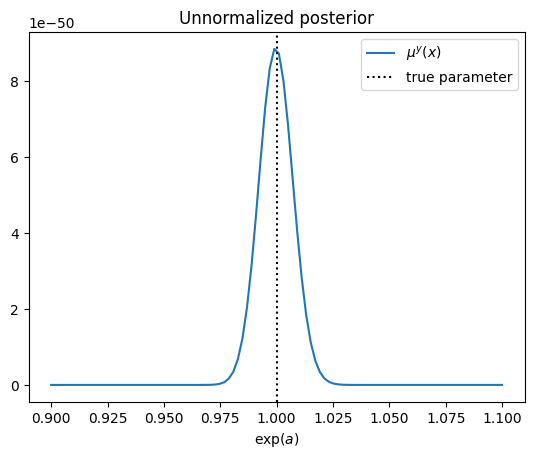

In [4]:
def posterior_unnormalized(x):
    return np.exp(-1/2*(np.linalg.norm(G(x).x.array - data.x.array)/delta)**2) * np.exp(-1/2*x**2)

posterior_unnormalized = np.vectorize(posterior_unnormalized)

xs = np.log(np.linspace(0.9, 1.1, 100))
plt.plot(np.exp(xs), posterior_unnormalized(xs), label="$\\mu^y(x)$")
plt.axvline(1, linestyle=":", color="black", label="true parameter")
plt.xlabel("$\\exp(a)$")
plt.legend()
plt.title("Unnormalized posterior")
plt.show()